In [3]:
from __future__ import annotations

import time
import warnings
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pybaseball import statcast
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

START_DATE = "2023-02-28"
END_DATE = "2025-11-28"
TEST_YEAR = 2025
DOWNLOAD_STEP_DAYS = 15
MAX_DOWNLOAD_ATTEMPTS = 3
RETRY_WAIT_SECONDS = 2
MIN_EXPECTED_BIP_PER_YEAR = 80_000
HITTER_BASELINE_PRIOR_BIP = 75.0

CACHE_PATH = Path(
    f"statcast_bip_{START_DATE}_to_{END_DATE}_{DOWNLOAD_STEP_DAYS}d_complete.pkl"
)
CHUNK_CACHE_DIR = Path(
    f"statcast_bip_chunks_{START_DATE}_to_{END_DATE}_{DOWNLOAD_STEP_DAYS}d"
)
OUTPUT_PATH = Path("EV_LA_predictability_results.xlsx")

RUN_PERMUTATION_IMPORTANCE = True
IMPORTANCE_SAMPLE_SIZE = 5_000
IMPORTANCE_REPEATS = 3

TARGETS = {
    "launch_angle": "Launch Angle",
    "launch_speed": "Exit Velocity",
}



In [4]:
def _filter_official_bip(chunk: pd.DataFrame) -> pd.DataFrame:
    if chunk is None or chunk.empty:
        return pd.DataFrame()
    regular_season = chunk["game_type"].eq("R")
    official_bip = chunk["description"].eq("hit_into_play")
    if "type" in chunk.columns:
        official_bip = official_bip | chunk["type"].eq("X")
    return chunk.loc[regular_season & official_bip].copy()


def load_statcast_bip(
    start_date: str,
    end_date: str,
    step_days: int = DOWNLOAD_STEP_DAYS,
    cache_path: Path | None = None,
    chunk_cache_dir: Path | None = None,
    max_attempts: int = MAX_DOWNLOAD_ATTEMPTS,
) -> pd.DataFrame:
    if cache_path is not None and cache_path.exists():
        print(f"Loading verified combined cache: {cache_path.resolve()}")
        return pd.read_pickle(cache_path)

    start = datetime.strptime(start_date, "%Y-%m-%d")
    end = datetime.strptime(end_date, "%Y-%m-%d")
    chunks: list[pd.DataFrame] = []
    failures: list[dict[str, str]] = []
    current = start

    if chunk_cache_dir is not None:
        chunk_cache_dir.mkdir(parents=True, exist_ok=True)

    while current <= end:
        chunk_end_dt = min(current + timedelta(days=step_days - 1), end)
        chunk_start = current.strftime("%Y-%m-%d")
        chunk_end = chunk_end_dt.strftime("%Y-%m-%d")
        chunk_cache_path = None
        if chunk_cache_dir is not None:
            chunk_cache_path = chunk_cache_dir / f"{chunk_start}_to_{chunk_end}.pkl"

        if chunk_cache_path is not None and chunk_cache_path.exists():
            print(f"Loading completed chunk: {chunk_start} through {chunk_end}")
            filtered_chunk = pd.read_pickle(chunk_cache_path)
            if not filtered_chunk.empty:
                chunks.append(filtered_chunk)
            current = chunk_end_dt + timedelta(days=1)
            continue

        last_error = None
        filtered_chunk = None
        for attempt in range(1, max_attempts + 1):
            print(
                f"Downloading {chunk_start} through {chunk_end} "
                f"(attempt {attempt}/{max_attempts})"
            )
            try:
                raw_chunk = statcast(start_dt=chunk_start, end_dt=chunk_end)
                filtered_chunk = _filter_official_bip(raw_chunk)
                last_error = None
                break
            except Exception as exc:
                last_error = exc
                print(f"Attempt {attempt} failed: {exc}")
                if attempt < max_attempts:
                    time.sleep(RETRY_WAIT_SECONDS * attempt)

        if last_error is not None or filtered_chunk is None:
            failures.append(
                {"start": chunk_start, "end": chunk_end, "error": str(last_error)}
            )
        else:
            if chunk_cache_path is not None:
                filtered_chunk.to_pickle(chunk_cache_path)
            if not filtered_chunk.empty:
                chunks.append(filtered_chunk)
        current = chunk_end_dt + timedelta(days=1)

    if failures:
        failure_text = "\n".join(
            f"- {item['start']} through {item['end']}: {item['error']}"
            for item in failures
        )
        raise RuntimeError(
            "Some Statcast ranges failed after all retries. No combined cache "
            "was written. Rerun this cell; completed chunks will be reused.\n"
            f"{failure_text}"
        )
    if not chunks:
        raise ValueError("No regular-season balls in play were downloaded.")

    data = pd.concat(chunks, ignore_index=True)
    if cache_path is not None:
        data.to_pickle(cache_path)
        print(f"Saved verified combined cache: {cache_path.resolve()}")
    return data


df = load_statcast_bip(
    START_DATE,
    END_DATE,
    step_days=DOWNLOAD_STEP_DAYS,
    cache_path=CACHE_PATH,
    chunk_cache_dir=CHUNK_CACHE_DIR,
)

df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")
df["game_year"] = pd.to_numeric(df["game_year"], errors="coerce")
for target in TARGETS:
    df[target] = pd.to_numeric(df[target], errors="coerce")
df = df.dropna(subset=["game_date", "game_year", *TARGETS]).copy()

pitch_key = [
    column
    for column in ["game_pk", "at_bat_number", "pitch_number"]
    if column in df.columns
]
if len(pitch_key) == 3:
    before = len(df)
    df = df.drop_duplicates(subset=pitch_key, keep="last").copy()
    print(f"Removed {before - len(df):,} duplicated pitch rows.")

season_audit = (
    df.groupby("game_year", observed=True)
    .agg(
        BIP=("game_date", "size"),
        First_Game_Date=("game_date", "min"),
        Last_Game_Date=("game_date", "max"),
        Games=("game_pk", "nunique"),
    )
    .reset_index()
)
season_audit["game_year"] = season_audit["game_year"].astype(int)

df["year_month"] = df["game_date"].dt.to_period("M").astype(str)
monthly_counts = (
    df.groupby(["game_year", "year_month"], observed=True)
    .size()
    .rename("BIP")
    .reset_index()
)
monthly_counts["game_year"] = monthly_counts["game_year"].astype(int)
display(season_audit)
display(monthly_counts)

expected_years = list(
    range(datetime.strptime(START_DATE, "%Y-%m-%d").year, TEST_YEAR + 1)
)
season_counts = season_audit.set_index("game_year")["BIP"]
incomplete_years = {
    year: int(season_counts.get(year, 0))
    for year in expected_years
    if int(season_counts.get(year, 0)) < MIN_EXPECTED_BIP_PER_YEAR
}
if incomplete_years:
    raise RuntimeError(
        "The season-completeness audit failed. Expected at least "
        f"{MIN_EXPECTED_BIP_PER_YEAR:,} BIP per full season; found "
        f"{incomplete_years}. Delete the verified combined cache if it exists "
        "and rerun the download."
    )
print(f"Verified official balls in play: {len(df):,}")



Loading completed chunk: 2023-02-28 through 2023-03-14
Loading completed chunk: 2023-03-15 through 2023-03-29
This is a large query, it may take a moment to complete


100%|██████████| 15/15 [00:10<00:00,  1.42it/s]


This is a large query, it may take a moment to complete


100%|██████████| 15/15 [00:10<00:00,  1.44it/s]


Loading completed chunk: 2023-04-29 through 2023-05-13
Loading completed chunk: 2023-05-14 through 2023-05-28
Loading completed chunk: 2023-05-29 through 2023-06-12
Loading completed chunk: 2023-06-13 through 2023-06-27
Loading completed chunk: 2023-06-28 through 2023-07-12
Loading completed chunk: 2023-07-13 through 2023-07-27
Loading completed chunk: 2023-07-28 through 2023-08-11
Loading completed chunk: 2023-08-12 through 2023-08-26
Loading completed chunk: 2023-08-27 through 2023-09-10
Loading completed chunk: 2023-09-11 through 2023-09-25
Loading completed chunk: 2023-09-26 through 2023-10-10
Loading completed chunk: 2023-10-11 through 2023-10-25
Loading completed chunk: 2023-10-26 through 2023-11-09
Loading completed chunk: 2023-11-10 through 2023-11-24
Loading completed chunk: 2023-11-25 through 2023-12-09
Loading completed chunk: 2023-12-10 through 2023-12-24
Loading completed chunk: 2023-12-25 through 2024-01-08
Loading completed chunk: 2024-01-09 through 2024-01-23
Loading co

,game_year,BIP,First_Game_Date,Last_Game_Date,Games
0,2023,123886,2023-03-30,2023-10-01,2430
1,2024,123831,2024-03-20,2024-09-30,2429
2,2025,124450,2025-03-18,2025-09-28,2430


,game_year,year_month,BIP
0,2023,2023-03,965
1,2023,2023-04,20454
2,2023,2023-05,21293
3,2023,2023-06,19939
4,2023,2023-07,18662
5,2023,2023-08,21027
6,2023,2023-09,20813
7,2023,2023-10,733
8,2024,2024-03,2827
9,2024,2024-04,20152


Verified official balls in play: 372,167


In [ ]:
TARGET_DERIVED_COLUMNS = {
    "launch_speed", "launch_angle", "launch_speed_angle",
    "estimated_ba_using_speedangle", "estimated_woba_using_speedangle",
    "estimated_slg_using_speedangle", "woba_value", "woba_denom",
    "babip_value", "iso_value", "hyper_speed",
}
POST_CONTACT_COLUMNS = {
    "events", "description", "des", "bb_type", "hit_location",
    "hit_distance_sc", "hc_x", "hc_y", "post_away_score",
    "post_home_score", "post_bat_score", "post_fld_score",
    "delta_home_win_exp", "delta_run_exp", "delta_pitcher_run_exp",
}
BLOCKED_FEATURES = TARGET_DERIVED_COLUMNS | POST_CONTACT_COLUMNS

PITCH_NUMERIC_CANDIDATES = [
    "release_speed", "release_pos_x", "release_pos_z", "release_spin_rate",
    "release_extension", "pfx_x", "pfx_z", "arm_angle", "balls",
    "strikes", "outs_when_up", "inning", "bat_score_diff", "age_bat",
    "n_thruorder_pitcher", "n_priorpa_thisgame_player_at_bat",
    "batter_days_since_prev_game", "plate_x_batter_view",
    "plate_z_normalized",
]
SWING_TRACKING_NUMERIC = [
    "bat_speed", "swing_length", "attack_angle", "attack_direction",
    "swing_path_tilt",
]
CATEGORICAL_CANDIDATES = [
    "pitch_type", "stand", "p_throws", "count", "platoon_matchup",
]


def add_pre_contact_features(data: pd.DataFrame) -> pd.DataFrame:
    result = data.copy()
    balls = pd.to_numeric(result["balls"], errors="coerce")
    strikes = pd.to_numeric(result["strikes"], errors="coerce")
    result["count"] = (
        balls.fillna(-1).astype(int).astype(str)
        + "-"
        + strikes.fillna(-1).astype(int).astype(str)
    )
    stand = result["stand"]
    throws = result["p_throws"]
    result["platoon_matchup"] = np.where(
        stand.notna() & throws.notna(),
        np.where(stand.eq(throws), "same_side", "opposite_side"),
        "unknown",
    )
    plate_x = pd.to_numeric(result["plate_x"], errors="coerce")
    plate_z = pd.to_numeric(result["plate_z"], errors="coerce")
    sz_top = pd.to_numeric(result["sz_top"], errors="coerce")
    sz_bot = pd.to_numeric(result["sz_bot"], errors="coerce")
    zone_height = (sz_top - sz_bot).replace(0, np.nan)
    result["plate_x_batter_view"] = plate_x * stand.map({"R": 1.0, "L": -1.0})
    result["plate_z_normalized"] = (plate_z - sz_bot) / zone_height
    return result


df = add_pre_contact_features(df)
missing_tracking_columns = [
    column for column in SWING_TRACKING_NUMERIC if column not in df.columns
]
if missing_tracking_columns:
    raise ValueError(f"Required contact-time columns are missing: {missing_tracking_columns}")

coverage_rows = []
for year, year_df in df.groupby("game_year", observed=True):
    complete_tracking = year_df[SWING_TRACKING_NUMERIC].notna().all(axis=1)
    row = {
        "game_year": int(year),
        "All_BIP": len(year_df),
        "Matched_Tracked_BIP": int(complete_tracking.sum()),
        "Matched_Tracked_Pct": 100 * complete_tracking.mean(),
    }
    for column in SWING_TRACKING_NUMERIC:
        row[f"{column}_available_pct"] = 100 * year_df[column].notna().mean()
    coverage_rows.append(row)
coverage = pd.DataFrame(coverage_rows).sort_values("game_year")
display(coverage.round(1))

matched_df = df.dropna(subset=SWING_TRACKING_NUMERIC).copy()
pitch_numeric = [
    column for column in PITCH_NUMERIC_CANDIDATES if column in matched_df.columns
]
contact_numeric = pitch_numeric + SWING_TRACKING_NUMERIC
categorical_features = [
    column for column in CATEGORICAL_CANDIDATES if column in matched_df.columns
]
feature_sets = {
    "Pitch Only": {"numeric": pitch_numeric, "categorical": categorical_features},
    "Contact Time": {"numeric": contact_numeric, "categorical": categorical_features},
}

for feature_set_name, spec in feature_sets.items():
    features = spec["numeric"] + spec["categorical"]
    leaked = sorted(set(features) & BLOCKED_FEATURES)
    if leaked:
        raise AssertionError(f"Leakage detected in {feature_set_name}: {leaked}")
    print(
        f"{feature_set_name}: {len(spec['numeric'])} numeric and "
        f"{len(spec['categorical'])} categorical features"
    )
print("Leakage audit passed for both feature sets.")



,game_year,All_BIP,Matched_Tracked_BIP,Matched_Tracked_Pct,bat_speed_available_pct,swing_length_available_pct,attack_angle_available_pct,attack_direction_available_pct,swing_path_tilt_available_pct
0,2023,123886,51804,41.8,41.8,41.8,41.8,41.8,41.8
1,2024,123831,113792,91.9,91.9,91.9,91.9,91.9,91.9
2,2025,124450,119095,95.7,95.7,95.7,95.7,95.7,95.7


Pitch Only: 19 numeric and 5 categorical features
Contact Time: 24 numeric and 5 categorical features
Leakage audit passed for both feature sets.


In [6]:
train_df = matched_df.loc[matched_df["game_year"] < TEST_YEAR].copy()
test_df = matched_df.loc[matched_df["game_year"] == TEST_YEAR].copy()
if train_df.empty or test_df.empty:
    raise ValueError(
        f"The split failed: train rows={len(train_df):,}, test rows={len(test_df):,}."
    )
if train_df["game_date"].max() >= test_df["game_date"].min():
    raise AssertionError("Training and test dates overlap.")

print(
    f"Matched training cohort: {len(train_df):,} BIP from "
    f"{int(train_df['game_year'].min())}-{int(train_df['game_year'].max())}"
)
print(f"Matched test cohort:     {len(test_df):,} BIP from {TEST_YEAR}")
print(
    f"Test dates: {test_df['game_date'].min().date()} through "
    f"{test_df['game_date'].max().date()}"
)


def make_feature_matrix(
    data: pd.DataFrame, numeric: list[str], categorical: list[str]
) -> pd.DataFrame:
    X = data[numeric + categorical].copy()
    for column in numeric:
        X[column] = pd.to_numeric(X[column], errors="coerce")
    for column in categorical:
        X[column] = X[column].astype("string").fillna("Missing").astype(object)
    return X


X_train_by_set = {
    name: make_feature_matrix(train_df, spec["numeric"], spec["categorical"])
    for name, spec in feature_sets.items()
}
X_test_by_set = {
    name: make_feature_matrix(test_df, spec["numeric"], spec["categorical"])
    for name, spec in feature_sets.items()
}
y_train = {
    target: pd.to_numeric(train_df[target], errors="coerce").to_numpy()
    for target in TARGETS
}
y_test = {
    target: pd.to_numeric(test_df[target], errors="coerce").to_numpy()
    for target in TARGETS
}



Matched training cohort: 165,596 BIP from 2023-2024
Matched test cohort:     119,095 BIP from 2025
Test dates: 2025-03-18 through 2025-09-28


In [7]:
def hitter_history_predictions(
    training_data: pd.DataFrame,
    testing_data: pd.DataFrame,
    target: str,
    prior_bip: float = HITTER_BASELINE_PRIOR_BIP,
) -> tuple[np.ndarray, float, pd.DataFrame]:
    league_mean = float(training_data[target].mean())
    history = (
        training_data.groupby("batter", observed=True)[target]
        .agg(hitter_mean="mean", hitter_bip="size")
        .reset_index()
    )
    history["shrunk_hitter_mean"] = (
        history["hitter_bip"] * history["hitter_mean"] + prior_bip * league_mean
    ) / (history["hitter_bip"] + prior_bip)
    mapping = history.set_index("batter")["shrunk_hitter_mean"]
    predictions = testing_data["batter"].map(mapping).fillna(league_mean)
    return predictions.to_numpy(dtype=float), league_mean, history


baseline_predictions: dict[str, dict[str, np.ndarray]] = {}
hitter_histories: dict[str, pd.DataFrame] = {}
for target in TARGETS:
    hitter_pred, league_mean, history = hitter_history_predictions(
        train_df, test_df, target
    )
    baseline_predictions[target] = {
        "League Average": np.full(len(test_df), league_mean, dtype=float),
        "Hitter History": hitter_pred,
    }
    hitter_histories[target] = history
    known_hitter_pct = 100 * test_df["batter"].isin(history["batter"]).mean()
    print(
        f"{TARGETS[target]} league mean: {league_mean:.2f}; "
        f"test BIP from returning hitters: {known_hitter_pct:.1f}%"
    )



Launch Angle league mean: 13.33; test BIP from returning hitters: 91.6%
Exit Velocity league mean: 88.28; test BIP from returning hitters: 91.6%


In [8]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_model_templates(
    numeric: list[str], categorical: list[str]
) -> dict[str, Pipeline]:
    ridge_preprocessor = ColumnTransformer(
        [
            (
                "numeric",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric,
            ),
            ("categorical", make_one_hot_encoder(), categorical),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )
    tree_preprocessor = ColumnTransformer(
        [
            ("numeric", SimpleImputer(strategy="median", add_indicator=True), numeric),
            ("categorical", make_one_hot_encoder(), categorical),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )
    return {
        "Ridge": Pipeline(
            [("preprocessor", ridge_preprocessor), ("model", Ridge(alpha=10.0))]
        ),
        "HistGradientBoosting": Pipeline(
            [
                ("preprocessor", tree_preprocessor),
                (
                    "model",
                    HistGradientBoostingRegressor(
                        loss="squared_error",
                        learning_rate=0.05,
                        max_iter=300,
                        max_leaf_nodes=31,
                        min_samples_leaf=30,
                        l2_regularization=5.0,
                        early_stopping=False,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
    }


fitted_models: dict[str, dict[str, dict[str, Pipeline]]] = {}
model_predictions: dict[str, dict[str, dict[str, np.ndarray]]] = {}
for target, target_label in TARGETS.items():
    fitted_models[target] = {}
    model_predictions[target] = {}
    print(f"\nFitting models for {target_label}...")
    for feature_set_name, spec in feature_sets.items():
        templates = build_model_templates(spec["numeric"], spec["categorical"])
        fitted_models[target][feature_set_name] = {}
        model_predictions[target][feature_set_name] = {}
        for model_name, template in templates.items():
            model = clone(template)
            model.fit(X_train_by_set[feature_set_name], y_train[target])
            predictions = model.predict(X_test_by_set[feature_set_name])
            fitted_models[target][feature_set_name][model_name] = model
            model_predictions[target][feature_set_name][model_name] = predictions
            print(f"Finished {feature_set_name} - {model_name}")




Fitting models for Launch Angle...
Finished Pitch Only - Ridge
Finished Pitch Only - HistGradientBoosting
Finished Contact Time - Ridge
Finished Contact Time - HistGradientBoosting

Fitting models for Exit Velocity...
Finished Pitch Only - Ridge
Finished Pitch Only - HistGradientBoosting
Finished Contact Time - Ridge
Finished Contact Time - HistGradientBoosting


In [9]:
def metric_values(actual: np.ndarray, predicted: np.ndarray) -> dict[str, float]:
    return {
        "RMSE": float(np.sqrt(mean_squared_error(actual, predicted))),
        "MAE": float(mean_absolute_error(actual, predicted)),
        "Median_AE": float(median_absolute_error(actual, predicted)),
        "R2": float(r2_score(actual, predicted)),
    }


pitch_metric_rows = []
for target, target_label in TARGETS.items():
    for method, predictions in baseline_predictions[target].items():
        pitch_metric_rows.append(
            {
                "Target": target_label, "Feature_Set": "Baseline", "Method": method,
                **metric_values(y_test[target], predictions), "Test_BIP": len(test_df),
            }
        )
    for feature_set_name, methods in model_predictions[target].items():
        for method, predictions in methods.items():
            pitch_metric_rows.append(
                {
                    "Target": target_label, "Feature_Set": feature_set_name,
                    "Method": method, **metric_values(y_test[target], predictions),
                    "Test_BIP": len(test_df),
                }
            )

metrics = pd.DataFrame(pitch_metric_rows)
league_rmse = (
    metrics.loc[metrics["Method"].eq("League Average")]
    .set_index("Target")["RMSE"]
)
metrics["RMSE_Improvement_vs_League_Pct"] = metrics.apply(
    lambda row: 100
    * (league_rmse.loc[row["Target"]] - row["RMSE"])
    / league_rmse.loc[row["Target"]],
    axis=1,
)
metrics = metrics.sort_values(["Target", "RMSE"]).reset_index(drop=True)
display(metrics.round(3))

ablation_rows = []
for target, target_label in TARGETS.items():
    for model_name in ["Ridge", "HistGradientBoosting"]:
        pitch_rmse = metrics.loc[
            metrics["Target"].eq(target_label)
            & metrics["Feature_Set"].eq("Pitch Only")
            & metrics["Method"].eq(model_name), "RMSE"
        ].iloc[0]
        contact_rmse = metrics.loc[
            metrics["Target"].eq(target_label)
            & metrics["Feature_Set"].eq("Contact Time")
            & metrics["Method"].eq(model_name), "RMSE"
        ].iloc[0]
        ablation_rows.append(
            {
                "Target": target_label, "Method": model_name,
                "Pitch_Only_RMSE": pitch_rmse, "Contact_Time_RMSE": contact_rmse,
                "Contact_Time_RMSE_Improvement_Pct": 100
                * (pitch_rmse - contact_rmse) / pitch_rmse,
            }
        )
ablation_results = pd.DataFrame(ablation_rows)
display(ablation_results.round(3))

best_config_by_target: dict[str, tuple[str, str]] = {}
for target, target_label in TARGETS.items():
    best_row = (
        metrics.loc[
            metrics["Target"].eq(target_label)
            & ~metrics["Feature_Set"].eq("Baseline")
        ].sort_values("RMSE").iloc[0]
    )
    best_config_by_target[target] = (
        str(best_row["Feature_Set"]), str(best_row["Method"])
    )
print("Best fitted configuration by target:", best_config_by_target)



,Target,Feature_Set,Method,RMSE,MAE,Median_AE,R2,Test_BIP,RMSE_Improvement_vs_League_Pct
0,Exit Velocity,Contact Time,HistGradientBoosting,10.692,8.456,7.289,0.478,119095,27.770
1,Exit Velocity,Contact Time,Ridge,12.813,10.333,9.293,0.250,119095,13.442
2,Exit Velocity,Pitch Only,HistGradientBoosting,13.044,10.038,8.481,0.223,119095,11.881
3,Exit Velocity,Pitch Only,Ridge,14.545,11.448,10.040,0.033,119095,1.741
4,Exit Velocity,Baseline,Hitter History,14.673,11.583,10.269,0.016,119095,0.882
5,Exit Velocity,Baseline,League Average,14.803,11.689,10.323,-0.001,119095,0.000
6,Launch Angle,Contact Time,HistGradientBoosting,24.323,19.129,15.775,0.279,119095,15.105
7,Launch Angle,Contact Time,Ridge,25.525,19.857,16.069,0.206,119095,10.910
8,Launch Angle,Pitch Only,HistGradientBoosting,26.455,20.596,16.614,0.147,119095,7.663
9,Launch Angle,Pitch Only,Ridge,26.878,20.922,16.859,0.120,119095,6.189


,Target,Method,Pitch_Only_RMSE,Contact_Time_RMSE,Contact_Time_RMSE_Improvement_Pct
0,Launch Angle,Ridge,26.878,25.525,5.033
1,Launch Angle,HistGradientBoosting,26.455,24.323,8.059
2,Exit Velocity,Ridge,14.545,12.813,11.908
3,Exit Velocity,HistGradientBoosting,13.044,10.692,18.031


Best fitted configuration by target: {'launch_angle': ('Contact Time', 'HistGradientBoosting'), 'launch_speed': ('Contact Time', 'HistGradientBoosting')}


In [10]:
metadata_columns = [
    column for column in [
        "game_date", "game_year", "game_pk", "at_bat_number", "pitch_number",
        "batter", "pitcher", "pitch_type", "stand", "p_throws",
    ] if column in test_df.columns
]
predictions_df = test_df[metadata_columns].copy()
prediction_metadata = []


def safe_name(value: str) -> str:
    return value.lower().replace(" ", "_")


for target in TARGETS:
    predictions_df[f"actual_{target}"] = y_test[target]
    for method, values in baseline_predictions[target].items():
        column = f"pred_{target}_{safe_name(method)}"
        predictions_df[column] = values
        prediction_metadata.append(
            {"target": target, "feature_set": "Baseline", "method": method, "column": column}
        )
    for feature_set_name, methods in model_predictions[target].items():
        for method, values in methods.items():
            column = f"pred_{target}_{safe_name(feature_set_name)}_{safe_name(method)}"
            predictions_df[column] = values
            prediction_metadata.append(
                {"target": target, "feature_set": feature_set_name, "method": method, "column": column}
            )


def make_player_level_results(
    prediction_data: pd.DataFrame, min_test_bip: int = 25
) -> tuple[pd.DataFrame, pd.DataFrame]:
    measurement_columns = [
        column for column in prediction_data.columns
        if column.startswith("actual_") or column.startswith("pred_")
    ]
    grouped = prediction_data.groupby("batter", observed=True)
    player_means = grouped[measurement_columns].mean()
    player_means["Test_BIP"] = grouped.size()
    player_means = player_means.loc[player_means["Test_BIP"] >= min_test_bip]

    rows = []
    for item in prediction_metadata:
        target = item["target"]
        rows.append(
            {
                "Target": TARGETS[target], "Feature_Set": item["feature_set"],
                "Method": item["method"],
                **metric_values(
                    player_means[f"actual_{target}"].to_numpy(),
                    player_means[item["column"]].to_numpy(),
                ),
                "Qualified_Hitters": len(player_means),
                "Minimum_Test_BIP": min_test_bip,
            }
        )
    return player_means.reset_index(), pd.DataFrame(rows)


player_means, player_metrics = make_player_level_results(predictions_df, min_test_bip=25)
player_metrics = player_metrics.sort_values(["Target", "RMSE"]).reset_index(drop=True)
display(player_metrics.round(3))



,Target,Feature_Set,Method,RMSE,MAE,Median_AE,R2,Qualified_Hitters,Minimum_Test_BIP
0,Exit Velocity,Contact Time,HistGradientBoosting,1.708,1.326,1.096,0.637,553,25
1,Exit Velocity,Contact Time,Ridge,1.972,1.544,1.257,0.516,553,25
2,Exit Velocity,Baseline,Hitter History,2.185,1.629,1.206,0.406,553,25
3,Exit Velocity,Pitch Only,Ridge,2.737,2.161,1.763,0.067,553,25
4,Exit Velocity,Pitch Only,HistGradientBoosting,2.771,2.198,1.897,0.044,553,25
5,Exit Velocity,Baseline,League Average,2.834,2.238,1.882,-0.000,553,25
6,Launch Angle,Baseline,Hitter History,4.226,3.127,2.282,0.348,553,25
7,Launch Angle,Contact Time,HistGradientBoosting,4.437,3.499,2.767,0.282,553,25
8,Launch Angle,Contact Time,Ridge,4.774,3.724,3.019,0.168,553,25
9,Launch Angle,Baseline,League Average,5.235,4.154,3.375,-0.000,553,25


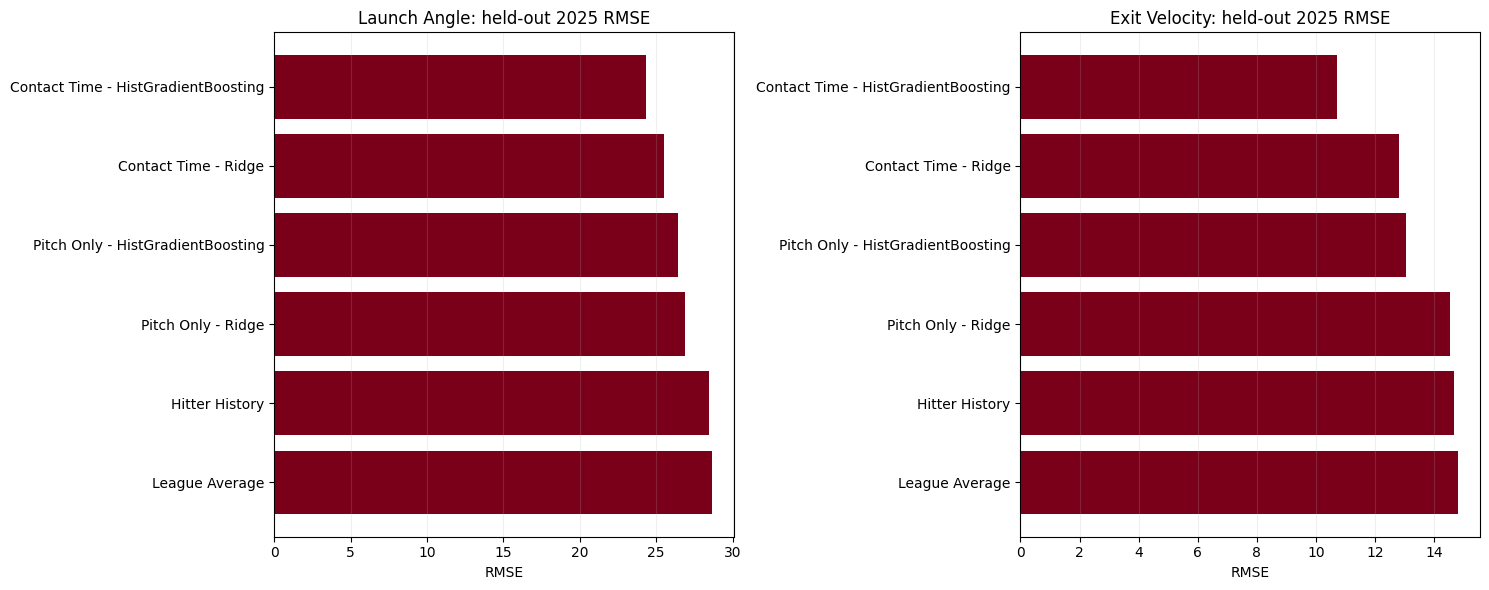

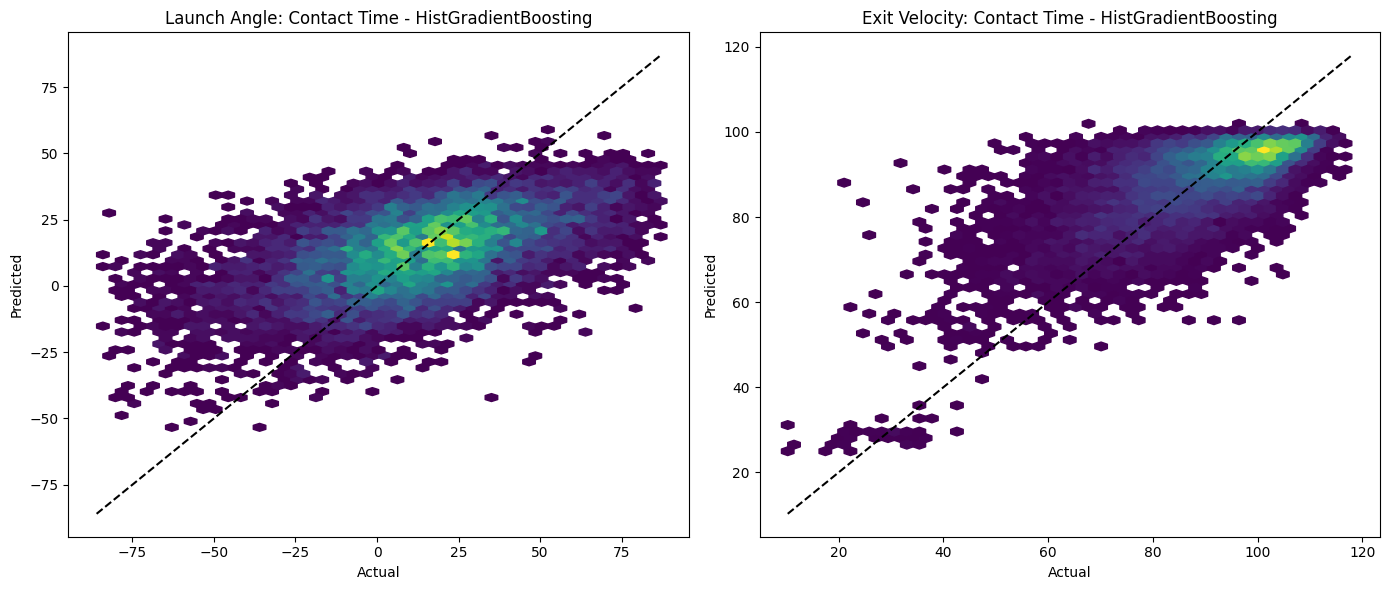

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, target_label in zip(axes, TARGETS.values()):
    plot_data = metrics.loc[metrics["Target"].eq(target_label)].copy()
    plot_data["Label"] = np.where(
        plot_data["Feature_Set"].eq("Baseline"), plot_data["Method"],
        plot_data["Feature_Set"] + " - " + plot_data["Method"],
    )
    plot_data = plot_data.sort_values("RMSE")
    axis.barh(plot_data["Label"], plot_data["RMSE"], color="#7A0019")
    axis.set_title(f"{target_label}: held-out 2025 RMSE")
    axis.set_xlabel("RMSE")
    axis.invert_yaxis()
    axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for axis, (target, target_label) in zip(axes, TARGETS.items()):
    feature_set_name, model_name = best_config_by_target[target]
    predicted = model_predictions[target][feature_set_name][model_name]
    sample_size = min(10_000, len(test_df))
    rng = np.random.default_rng(RANDOM_STATE)
    sample_index = rng.choice(len(test_df), size=sample_size, replace=False)
    axis.hexbin(
        y_test[target][sample_index], predicted[sample_index], gridsize=45,
        mincnt=1, cmap="viridis",
    )
    low = min(y_test[target][sample_index].min(), predicted[sample_index].min())
    high = max(y_test[target][sample_index].max(), predicted[sample_index].max())
    axis.plot([low, high], [low, high], linestyle="--", color="black")
    axis.set_title(f"{target_label}: {feature_set_name} - {model_name}")
    axis.set_xlabel("Actual")
    axis.set_ylabel("Predicted")
plt.tight_layout()
plt.show()



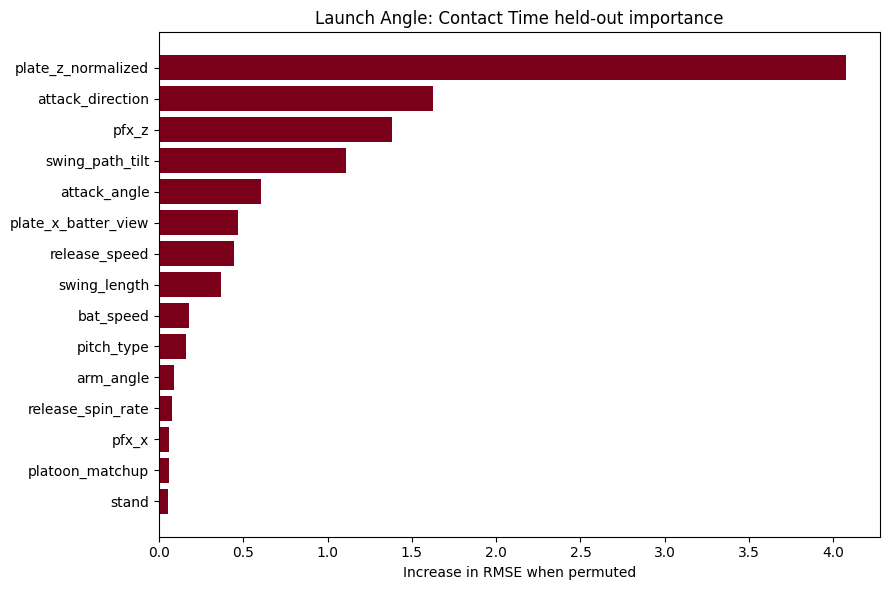

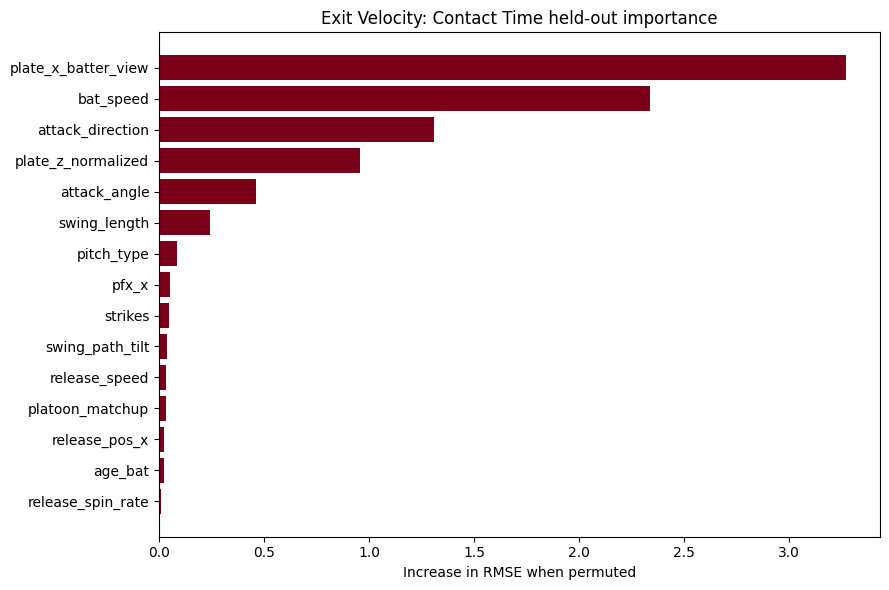

In [12]:
importance_tables: dict[str, pd.DataFrame] = {}
if RUN_PERMUTATION_IMPORTANCE:
    for target, target_label in TARGETS.items():
        feature_set_name, model_name = best_config_by_target[target]
        best_model = fitted_models[target][feature_set_name][model_name]
        X_test_selected = X_test_by_set[feature_set_name]
        feature_names = list(X_test_selected.columns)
        sample_size = min(IMPORTANCE_SAMPLE_SIZE, len(X_test_selected))
        importance_sample = X_test_selected.sample(n=sample_size, random_state=RANDOM_STATE)
        y_sample = test_df.loc[importance_sample.index, target]
        result = permutation_importance(
            best_model, importance_sample, y_sample,
            scoring="neg_root_mean_squared_error",
            n_repeats=IMPORTANCE_REPEATS,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
        table = pd.DataFrame(
            {
                "Feature_Set": feature_set_name, "Model": model_name,
                "Feature": feature_names,
                "Importance_Mean": result.importances_mean,
                "Importance_SD": result.importances_std,
            }
        ).sort_values("Importance_Mean", ascending=False)
        importance_tables[target] = table.reset_index(drop=True)
        top = table.head(15).sort_values("Importance_Mean")
        plt.figure(figsize=(9, 6))
        plt.barh(top["Feature"], top["Importance_Mean"], color="#7A0019")
        plt.title(f"{target_label}: {feature_set_name} held-out importance")
        plt.xlabel("Increase in RMSE when permuted")
        plt.tight_layout()
        plt.show()



In [ ]:
model_card = pd.DataFrame(
    {
        "Setting": [
            "Study", "Download range", "Download chunk size",
            "Maximum download attempts", "Training seasons", "Test season",
            "All downloaded BIP", "Matched train BIP", "Matched test BIP",
            "Matched test first date", "Matched test last date",
            "Hitter baseline prior BIP", "Random state", "Post-contact fields in X",
            "Feature-set comparison",
        ],
        "Value": [
            "Exit velocity and launch angle predictability",
            f"{START_DATE} through {END_DATE}", f"{DOWNLOAD_STEP_DAYS} days",
            MAX_DOWNLOAD_ATTEMPTS,
            f"{int(train_df['game_year'].min())}-{int(train_df['game_year'].max())}",
            TEST_YEAR, len(df), len(train_df), len(test_df),
            str(test_df["game_date"].min().date()),
            str(test_df["game_date"].max().date()),
            HITTER_BASELINE_PRIOR_BIP, RANDOM_STATE, "None - blocked by assertion",
            "Pitch Only and Contact Time use identical tracked BIP",
        ],
    }
)

feature_audit_rows = []
for feature_set_name, spec in feature_sets.items():
    for feature in spec["numeric"] + spec["categorical"]:
        feature_audit_rows.append(
            {"Feature_Set": feature_set_name, "Feature": feature, "Role": "Model input"}
        )
for feature in sorted(BLOCKED_FEATURES):
    feature_audit_rows.append(
        {"Feature_Set": "All", "Feature": feature, "Role": "Explicitly blocked"}
    )
feature_audit = pd.DataFrame(feature_audit_rows)

with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    metrics.to_excel(writer, sheet_name="Pitch Level Metrics", index=False)
    ablation_results.to_excel(writer, sheet_name="Ablation Results", index=False)
    player_metrics.to_excel(writer, sheet_name="Player Level Metrics", index=False)
    predictions_df.to_excel(writer, sheet_name="2025 Predictions", index=False)
    player_means.to_excel(writer, sheet_name="2025 Player Means", index=False)
    season_audit.to_excel(writer, sheet_name="Season Audit", index=False)
    monthly_counts.to_excel(writer, sheet_name="Monthly Counts", index=False)
    coverage.to_excel(writer, sheet_name="Data Coverage", index=False)
    model_card.to_excel(writer, sheet_name="Model Card", index=False)
    feature_audit.to_excel(writer, sheet_name="Feature Audit", index=False)
    for target, table in importance_tables.items():
        sheet_name = "LA Importance" if target == "launch_angle" else "EV Importance"
        table.to_excel(writer, sheet_name=sheet_name, index=False)
print(f"Saved results to: {OUTPUT_PATH.resolve()}")


def player_season_summary(
    batter_id: int, prediction_data: pd.DataFrame = predictions_df
) -> pd.DataFrame:
    player = prediction_data.loc[prediction_data["batter"].eq(batter_id)].copy()
    if player.empty:
        raise ValueError(f"No held-out 2025 BIP found for batter ID {batter_id}.")
    rows = []
    for item in prediction_metadata:
        target = item["target"]
        actual_column = f"actual_{target}"
        prediction_column = item["column"]
        rows.append(
            {
                "Batter": batter_id, "Target": TARGETS[target],
                "Feature_Set": item["feature_set"], "Method": item["method"],
                "BIP": len(player), "Actual_Mean": player[actual_column].mean(),
                "Predicted_Mean": player[prediction_column].mean(),
                "Mean_Difference": player[prediction_column].mean()
                - player[actual_column].mean(),
                "Pitch_Level_RMSE": np.sqrt(
                    mean_squared_error(player[actual_column], player[prediction_column])
                ),
            }
        )
    return pd.DataFrame(rows)

freeman_summary = player_season_summary(518692)
display(freeman_summary.round(3))

Saved results to: C:\Users\brend\Downloads\EV_LA_predictability_results.xlsx


,Batter,Target,Feature_Set,Method,BIP,Actual_Mean,Predicted_Mean,Mean_Difference,Pitch_Level_RMSE
0,518692,Launch Angle,Baseline,League Average,414,14.548,13.331,-1.218,25.877
1,518692,Launch Angle,Baseline,Hitter History,414,14.548,14.670,0.122,25.848
2,518692,Launch Angle,Pitch Only,Ridge,414,14.548,14.147,-0.401,25.326
3,518692,Launch Angle,Pitch Only,HistGradientBoosting,414,14.548,12.278,-2.270,24.738
4,518692,Launch Angle,Contact Time,Ridge,414,14.548,16.933,2.384,23.219
5,518692,Launch Angle,Contact Time,HistGradientBoosting,414,14.548,15.723,1.174,21.561
6,518692,Exit Velocity,Baseline,League Average,414,90.565,88.277,-2.288,13.164
7,518692,Exit Velocity,Baseline,Hitter History,414,90.565,89.131,-1.434,13.042
8,518692,Exit Velocity,Pitch Only,Ridge,414,90.565,88.826,-1.739,12.857
9,518692,Exit Velocity,Pitch Only,HistGradientBoosting,414,90.565,88.775,-1.790,10.925
